# Does it produce the image we expect?

[`01_build.ipynb`](01_build.ipynb) checked the sequence against arithmetic: areas, moments, timing,
the nominal k-space. Everything it asserted would still hold for a sequence that produced a
mirrored image, or one shifted half a pixel, or one whose phase encoding ran backwards.

This notebook takes the three `.seq` files that notebook wrote, simulates them against a BrainWeb
phantom, reconstructs them, and asks what the **sampling** cost.

**Needs `seqcraft[sim,recon]`** — MRzeroCore, torch and sigpy — and a one-off ~19 MB phantom
download. `01` needs none of that.

### The order things are settled in

1. **the slice axis** — a one-voxel-thick phantom reads a slice-select gradient as complete
   dephasing and returns *exactly zero* signal, so the phantom is a slab spanning the slice
2. **the fully sampled image** — the parsed trajectory against `01`'s nominal one, then a plain
   centred `ifft2` written out once
3. **only then, the comparison** — one reconstruction across three samplings

MRzero's own API throughout. There is no seqcraft bridge: `mr0.Sequence.import_file` parses the
`.seq` file the scanner would play, which makes this a check on the **file** rather than on the
tree that produced it.

In [1]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import torch

plt.rcParams['figure.dpi'] = 56          # keeps the committed notebook a readable size

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'gre_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
NX, NY = MATRIX

patterns = {name: tuple(int(v) for v in nominal[f'lines_{name}'])
            for name in ('full', 'uniform', 'vardens')}

for name, lines in patterns.items():
    print(f'{name:8s} {len(lines):3d} of {NY} lines   R = {NY / len(lines):.2f}   '
          f'-> {SEQ_DIR / f"gre_2d_{name}.seq"}')
print(f'\nTE {float(nominal["te_s"]) * 1e3:.3f} ms   TR {float(nominal["tr_s"]) * 1e3:.3f} ms   '
      f'{int(nominal["dummies"])} dummies')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


full     128 of 128 lines   R = 1.00   -> seq\gre_2d_full.seq
uniform   32 of 128 lines   R = 4.00   -> seq\gre_2d_uniform.seq
vardens   32 of 128 lines   R = 4.00   -> seq\gre_2d_vardens.seq

TE 3.368 ms   TR 10.000 ms   5 dummies


## 1. A BrainWeb phantom, and the risk that has to be settled first

MRzero ships the BrainWeb subjects as map stacks — PD, T1, T2, T2′ and D on a 128³ grid over
192 mm — which is what makes the contrast below worth looking at: grey matter, white matter and
CSF differ in all three, so the image tells you which weighting the protocol actually landed on,
and no synthetic disc phantom can. The acquisition matrix is 128 as well, so the phantom is
simulated at its own resolution and nothing is resampled on the way in.

**A one-voxel-thick phantom returns exactly zero signal.** The excitation's selection gradient
dephases across the slice; with a single voxel along z there is nothing to average that dephasing
over, so the simulator sees complete cancellation. `import_file` has no axis filter, so the fix is
on the phantom side: take a **slab** of slices spanning the slice the sequence excites, and put it
at isocentre, which is where the sequence excites.

**Coil sensitivities are not optional here.** BrainWeb ships one uniform coil, and a single
uniform coil measures one number per k-space sample — so an undersampled trajectory would have
genuinely fewer measurements than unknowns, and no algorithm recovers what was never encoded. The
aliasing would be a property of the experiment rather than of the reconstruction. So the notebook
attaches a receive ring, and §4 is about what that ring can and cannot do.

### Six maps, and all six are simulated

Nothing here is a switch to turn on: `phantom.build()` hands every map to the simulator, so a
gradient echo sees all of them at once. What is worth knowing is **which came from the file and
which did not**:

| | | from |
|---|---|---|
| PD, T1, T2 | the contrast the protocol is choosing between | the BrainWeb file |
| **T2′** | the *reversible* dephasing — the difference between T2 and T2\*, and the reason a gradient echo decays faster than a spin echo | the BrainWeb file |
| **D** | the diffusion coefficient, in µm²/ms | the BrainWeb file |
| **B0** | off-resonance in Hz, which a gradient echo accrues as phase over TE | **synthesised** |
| B1 | transmit profile, so the flip angle is not uniform | **synthesised** |

The last two are not in `subject05.npz`. `VoxelGridPhantom.load` notices and calls
`generate_B0_B1(PD)`, which fits a plausible field to the proton density and normalises it so the
PD-weighted mean off-resonance is zero and the mean B1 is one. That is a *model*, not a
measurement, and it matters here: at TE = 3.4 ms a ±50 Hz field is ±60° of phase, which the
root-sum-of-squares image below hides and a phase image would not.

In [2]:
PHANTOM_URL = ('https://github.com/MRsources/MRzero-Core/raw/main/'
               'documentation/playground_mr0/subject05.npz')
# ../data rather than ./data: a phantom is not this example's, and the next one should find it
# already downloaded rather than fetch its own copy.
PHANTOM = Path('../data/subject05.npz')

if not PHANTOM.exists():
    PHANTOM.parent.mkdir(parents=True, exist_ok=True)
    print(f'downloading {PHANTOM_URL} -> {PHANTOM} (~19 MB, once)')
    urllib.request.urlretrieve(PHANTOM_URL, PHANTOM)

SIM_N = 128                 # BrainWeb's own in-plane resolution: no resampling at all
NZ = 4                      # slices in the slab -- see above
N_COILS = 8


def coil_ring(nx, ny, nz, n_coils=N_COILS):
    """A ring of `n_coils` surface coils around the object, as complex sensitivities."""
    gx, gy = np.meshgrid(np.linspace(-1, 1, nx), np.linspace(-1, 1, ny), indexing='ij')
    sens = np.stack([
        np.exp(-((gx - 1.5 * np.cos(a)) ** 2 + (gy - 1.5 * np.sin(a)) ** 2) / 1.5)
        * np.exp(1j * np.arctan2(gy - np.sin(a), gx - np.cos(a)))
        for a in np.arange(n_coils) * 2 * np.pi / n_coils
    ]).astype(np.complex64)
    return torch.tensor(np.repeat(sens[:, :, :, None], nz, axis=3))


def slab(z_center=64, nz=NZ, n=SIM_N):
    """A BrainWeb slab of `nz` slices, resampled in plane and centred on isocentre."""
    whole = mr0.VoxelGridPhantom.load(PHANTOM).interpolate(n, n, 128)
    first = z_center - nz // 2
    out = whole.slices(list(range(first, first + nz)))
    # slices() leaves the slab where it was in the original volume.  Put it at isocentre, which
    # is where the sequence excites -- otherwise the slice profile selects the wrong tissue, or
    # none at all, and the symptom is a dark image rather than an error.
    out.affine[2, 3] = -0.5 * nz * float(out.affine[2, 2])
    return out


phantom = slab()
phantom.coil_sens = coil_ring(SIM_N, SIM_N, NZ)
data = phantom.build()

print(f'{tuple(phantom.PD.shape)} voxels, {N_COILS} coils')
print(f'in plane   {float(phantom.affine[0, 0]):.2f} mm/voxel over '
      f'{float(phantom.size[0]) * 1e3:.0f} mm')
print(f'along z    {float(phantom.affine[2, 2]):.2f} mm/voxel, '
      f'{float(phantom.size[2]) * 1e3:.1f} mm of slab from '
      f'{float(phantom.affine[2, 3]):+.2f} mm  '
      f'(the sequence excites {THICKNESS_MM:.0f} mm at isocentre)')

(128, 128, 4) voxels, 8 coils
in plane   1.50 mm/voxel over 192 mm
along z    1.50 mm/voxel, 6.0 mm of slab from -3.00 mm  (the sequence excites 5 mm at isocentre)


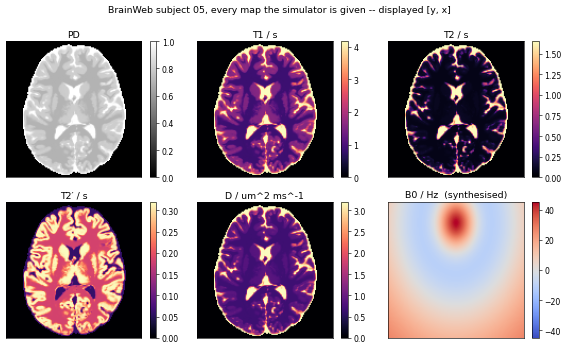

In [3]:
mid = NZ // 2
maps = [
    ('PD', phantom.PD, '', 'gray'),
    ('T1 / s', phantom.T1, '', 'magma'),
    ('T2 / s', phantom.T2, '', 'magma'),
    ('T2′ / s', phantom.T2dash, '', 'magma'),
    ('D / um^2 ms^-1', phantom.D, '', 'magma'),
    ('B0 / Hz  (synthesised)', phantom.B0, '', 'coolwarm'),
]

fig, axes = plt.subplots(2, 3, figsize=(10.4, 6.2))
for ax, (label, tensor, _unit, cmap) in zip(axes.ravel(), maps):
    # .T because the phantom is indexed [x, y] and an image is displayed [row, column] = [y, x].
    plane = tensor[:, :, mid].numpy().T
    limit = np.abs(plane).max()
    im = ax.imshow(plane, origin='lower', cmap=cmap,
                   **({'vmin': -limit, 'vmax': limit} if cmap == 'coolwarm' else {}))
    ax.set(title=label, xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('BrainWeb subject 05, every map the simulator is given -- displayed [y, x]', y=1.0)
fig.tight_layout()

## 2. `to_grid`, and settling the orientation

`to_grid` is the one function this notebook writes rather than imports, because **it is where a
transpose or a flipped line direction enters**. One repetition per TR, one TR per entry of
`lines`, so sample block *n* lands in row `lines[n]` of a `(coils, ny, nx)` array — and everything
not in `lines` stays zero.

The `LIN` labels in the `.seq` are the independent record it can be checked against: `01` wrote
one per acquired readout, so the file itself says where each block of samples belongs.

**Two index orders meet here, and they are not the same one.** A `VoxelGridPhantom` is indexed
`[x, y, z]`; a reconstructed image comes out of `ifft2` indexed `[row, column]`, which is
`[ky, kx]` and therefore `[y, x]`. So there is exactly one transpose between the two, it belongs at
display time, and every `imshow` below carries it explicitly rather than leaving it implied.

In [4]:
def to_grid(signal, lines, matrix=MATRIX):
    """Scatter one repetition per TR into a (coils, ny, nx) array, zeros where unsampled."""
    nx, ny = matrix
    samples = np.asarray(signal).reshape(len(lines), nx, -1)     # (line, sample, coil)
    grid = np.zeros((samples.shape[2], ny, nx), dtype=np.complex64)
    grid[:, list(lines), :] = samples.transpose(2, 0, 1)
    return grid


def simulate(name):
    """Import the written .seq, simulate it, and grid what came back."""
    seq = mr0.Sequence.import_file(str(SEQ_DIR / f'gre_2d_{name}.seq'))
    signal = mr0.execute_graph(mr0.compute_graph(seq, data), seq, data)
    return to_grid(signal, patterns[name])


def ifft2c(ksp):
    """The centred inverse FFT, written out once so its conventions are visible."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(ksp, axes=(-2, -1)),
                                        norm='ortho'), axes=(-2, -1))


def rss(image):
    """Root sum of squares across the coil axis."""
    return np.sqrt((np.abs(image) ** 2).sum(0))

## 3. The fully sampled image

Two things to check before believing anything downstream: that the trajectory the simulator parsed
out of the file is the nominal one `01` computed, and that a plain centred inverse FFT of the fully
sampled data looks like the object.

In [5]:
seq_full = mr0.Sequence.import_file(str(SEQ_DIR / 'gre_2d_full.seq'))
k_parsed = seq_full.get_kspace()[:, :3].numpy().T.reshape(3, len(patterns['full']), NX)

worst = np.abs(k_parsed[:2] - nominal['k_full'][:2]).max() / (1e3 / FOV_MM[0])
print(f'parsed vs nominal k, worst axis-wise difference: {worst:.2e} dk')
# In dk rather than in 1/m, and loose enough for the .seq file's own quantisation: a pulseq file
# stores gradient amplitudes to finite precision, so a perfect writer and a perfect parser still
# differ in the last digits.  What this catches is a sign, a swap or a shift.
assert worst < 1e-3

ksp = {name: simulate(name) for name in patterns}
zf = {name: rss(ifft2c(k)) for name, k in ksp.items()}
print(f'\nsampled k-space: {ksp["full"].shape} (coils, ny, nx)')

parsed vs nominal k, worst axis-wise difference: 1.62e-04 dk


Calculating repetitions:   0%|          | 0/133 [00:00<?, ?it/s]

Done.


Calculating repetitions:   0%|          | 0/37 [00:00<?, ?it/s]

Done.


Calculating repetitions:   0%|          | 0/37 [00:00<?, ?it/s]

Done.

sampled k-space: (8, 128, 128) (coils, ny, nx)


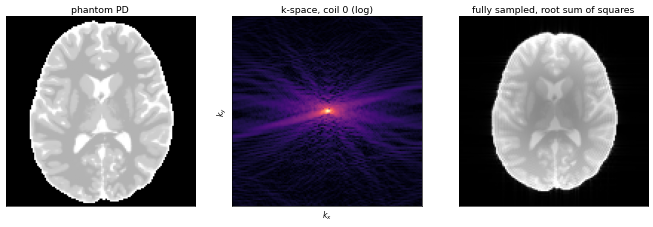

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
axes[0].imshow(phantom.PD[:, :, mid].numpy().T, origin='lower', cmap='gray')
axes[0].set(title='phantom PD', xticks=[], yticks=[])
axes[1].imshow(np.log1p(np.abs(ksp['full'][0])), origin='lower', cmap='magma', aspect='equal')
axes[1].set(title='k-space, coil 0 (log)', xlabel='$k_x$', ylabel='$k_y$', xticks=[], yticks=[])
axes[2].imshow(zf['full'], origin='lower', cmap='gray',vmin=0, vmax=zf['full'].max()*0.8)
axes[2].set(title='fully sampled, root sum of squares', xticks=[], yticks=[])
fig.tight_layout()

A 5° flip at TR = 15 ms sits **below** the ~10° Ernst angle for white matter, which is the
protocol choosing proton-density weighting over T1 weighting: CSF stays bright rather than
saturating out, and the grey/white separation is closer to the PD map than to the T1 map. Compare
the three maps above — that is what the flip angle bought, and the same sequence at 15° would show
the opposite trade.

The reference for "did the *reconstruction* work?" is not the PD map either way; it is the fully
sampled image itself, which is what §4 uses.

## 4. What the sampling costs

**One algorithm across three samplings.** The question is what the *sampling* costs, so holding the
reconstruction fixed is what makes the answer attributable — a grid of algorithms would answer a
different question.

`TotalVariationRecon` is the one to hold fixed, because it is the only one of the three that can
exploit what variable density buys. Uniform undersampling aliases **coherently**: the missing lines
put a small number of sharp replicas on top of the image. Variable density aliases
**incoherently**, which is noise-like, and removing noise-like structure is what a sparsity prior
is for.

The two patterns acquire the **same number of lines**, so whatever separates them is the
distribution rather than the budget.

Coil sensitivities come from ESPIRiT, which is why both undersampled patterns carry a fully sampled
calibration block at the centre of k-space.

The two undersampled patterns acquire the **same number of lines**, so what the table below
compares is *distributions*, not acceleration factors.

Expect the two to land close together, and read that as the result rather than as a null one.
Uniform undersampling aliases coherently, which is precisely what an eight-channel array is built
to unfold — at R ≈ 2.9 the coils are doing nearly all the work and are not much troubled by how the
aliasing is distributed. The distribution starts to matter once the acceleration passes what the
array can unfold, because past that point the sparsity prior is the only thing left, and a prior can
only remove what it can tell apart from the object.

In [7]:
import sigpy.mri as smri

mps = smri.app.EspiritCalib(ksp['full'], show_pbar=False).run()
print('coil maps from the fully sampled data:', mps.shape)

recon = {}
for name in patterns:
    # recon[name] = np.abs(smri.app.SenseRecon(
    recon[name] = np.abs(smri.app.L1WaveletRecon(
        ksp[name], mps, lamda=1e-4, max_iter=100, show_pbar=False).run())
    print(f'{name:8s} reconstructed')

coil maps from the fully sampled data: (8, 128, 128)


full     reconstructed


uniform  reconstructed


vardens  reconstructed


pattern     lines      R  zero-filled  WAVELET
full          128   1.00        0.009    0.000
uniform        32   4.00        0.194    0.067
vardens        32   4.00        0.168    0.063


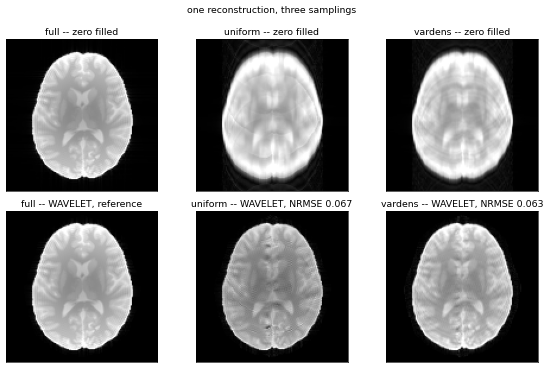

In [8]:
reference = recon['full']


def nrmse(image, target=reference):
    """Normalised root-mean-square error against the fully sampled reconstruction."""
    scale = float((image * target).sum() / max((image * image).sum(), 1e-12))
    return float(np.sqrt(((scale * image - target) ** 2).mean()) / target.std())


fig, axes = plt.subplots(2, 3, figsize=(10.4, 6.6))
for column, name in enumerate(patterns):
    axes[0, column].imshow(zf[name], origin='lower', cmap='gray', vmin=0, vmax=zf[name].max()*0.8)
    axes[0, column].set(title=f'{name} -- zero filled', xticks=[], yticks=[])
    axes[1, column].imshow(recon[name], origin='lower', cmap='gray', vmin=0, vmax=recon[name].max()*0.8)
    label = 'reference' if name == 'full' else f'NRMSE {nrmse(recon[name]):.3f}'
    axes[1, column].set(title=f'{name} -- WAVELET, {label}', xticks=[], yticks=[])
fig.suptitle('one reconstruction, three samplings', y=0.99)
fig.tight_layout()

print(f'{"pattern":10s} {"lines":>6s} {"R":>6s} {"zero-filled":>12s} {"WAVELET":>8s}')
for name, lines in patterns.items():
    print(f'{name:10s} {len(lines):6d} {NY / len(lines):6.2f} '
          f'{nrmse(zf[name]):12.3f} {nrmse(recon[name]):8.3f}')